</head>
<body>
    <h1>Customer Purchase Behavior Analysis</h1>
    <h2>Business Problem Statement</h2>
    <p>Retail businesses need insights into customer purchasing patterns to optimize inventory and promotions.</p>
    <h2>What to Do:</h2>
    <ul>
        <li>Use a transaction dataset.</li>
        <li>Analyze customer purchase patterns based on demographics or product categories.</li>
        <li>Visualize customer segments using bar charts and heatmaps.</li>
        <li>Summarize common purchasing trends and insights into seasonal behaviors.</li>
    </ul>
</body>
</html>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 

In [7]:
dataset = pd.read_csv('shopping_trends.csv')

In [9]:
dataset.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


#### Shape 

In [11]:
dataset.shape

(3900, 19)

### Info dataset 

In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

# Missing values 

In [14]:
dataset.isna().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

### Describe data 

In [20]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3900.0,3.749949,0.716223,2.5,3.10,3.7,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


# Explotary Data Analysis 

#### Which age category of people continuously purchases products?

In [29]:
ageBins = [18, 25, 34, 44, 54, 64, 70, 100]
ageLabels = ['18-25', '26-34', '35-44', '45-54', '55-64', '65-70', '70+']

ageCategory = pd.DataFrame(pd.cut(dataset['Age'], bins =ageBins, labels = ageLabels, right = False))
ageCategory['Frequency of Purchases'] = dataset['Frequency of Purchases']

In [31]:
ageCategory.head()

,Age,Frequency of Purchases
0,55-64,Fortnightly
1,18-25,Fortnightly
2,45-54,Weekly
3,18-25,Weekly
4,45-54,Annually


Text(0.5, 0, 'Age Category')

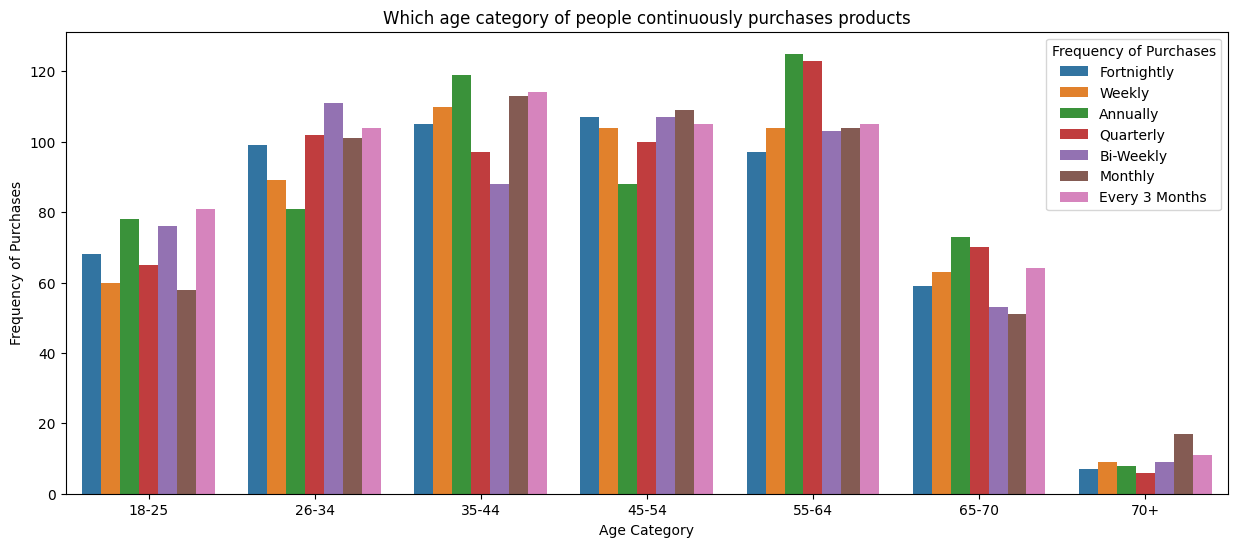

In [143]:
plt.figure(figsize=(15, 6))
ax = sns.countplot(data = ageCategory, x = "Age", hue = "Frequency of Purchases")
plt.title("Which age category of people continuously purchases products")
plt.ylabel("Frequency of Purchases")
plt.xlabel("Age Category")

### How many loyal customers continuously purchase the product in their age category?

In [66]:
loyal_customers = dataset[dataset['Subscription Status'] == 'Yes']
loyal_customers["Age Category"] = ageCategory['Age']

C:\Users\User\AppData\Local\Temp\ipykernel_5548\4085803233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loyal_customers["Age Category"] = ageCategory['Age']


In [68]:
loyal_customers = loyal_customers.groupby(["Age Category", "Frequency of Purchases"]).size().reset_index(name = "Customer_count")

In [69]:
loyal_customers.head()

,Age Category,Frequency of Purchases,Customer_count
0,18-25,Annually,22
1,18-25,Bi-Weekly,18
2,18-25,Every 3 Months,21
3,18-25,Fortnightly,16
4,18-25,Monthly,17


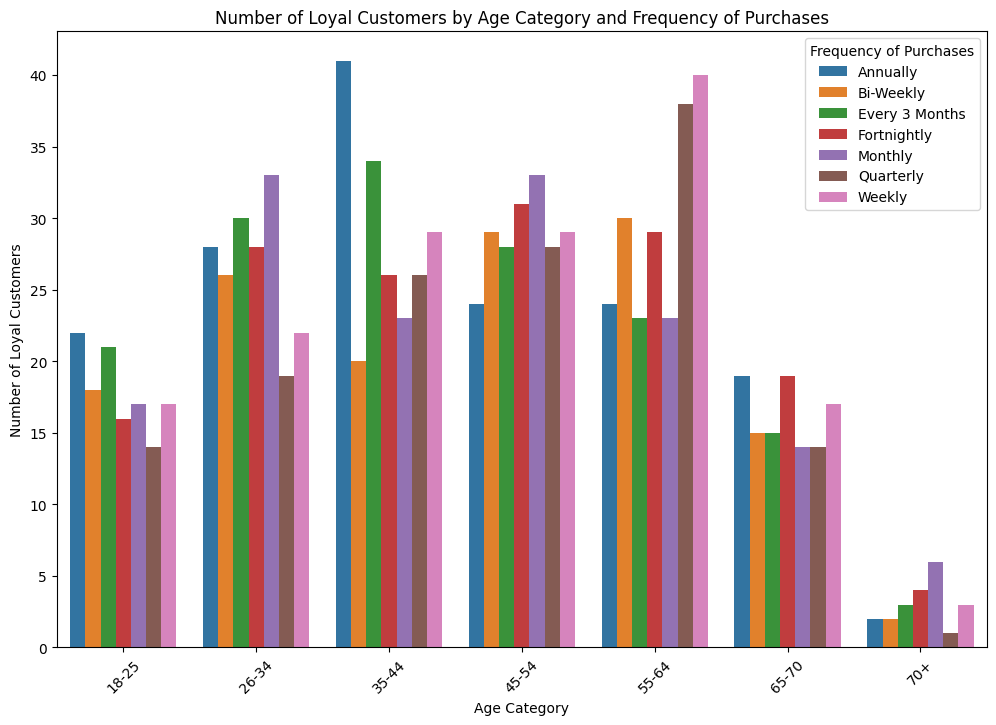

In [74]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Age Category', y='Customer_count', hue='Frequency of Purchases', data=loyal_customers)
plt.title('Number of Loyal Customers by Age Category and Frequency of Purchases')
plt.xlabel('Age Category')
plt.ylabel('Number of Loyal Customers')
plt.xticks(rotation=45)
plt.show()

# Which location has the highest product purchases ? 

In [90]:
locationPurchase = dataset.groupby("Location")['Purchase Amount (USD)'].sum().reset_index()

In [94]:
headMapData = locationPurchase.set_index('Location').T

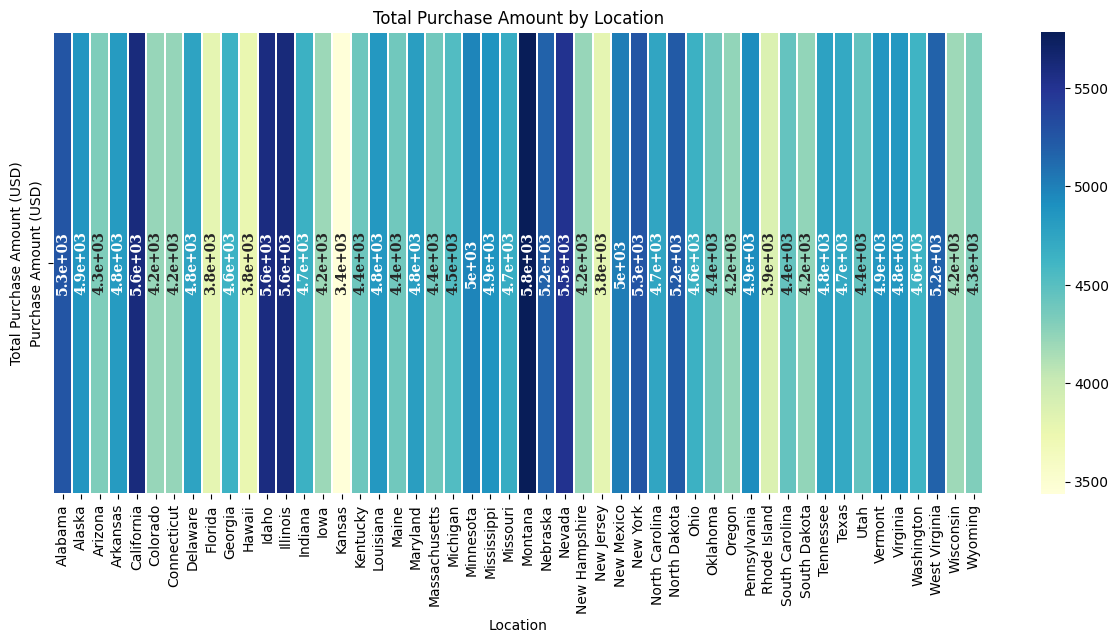

In [110]:
plt.figure(figsize=(15, 6))
sns.heatmap(headMapData, annot=True, cmap='YlGnBu', cbar=True, linewidths=0.10, annot_kws={"rotation": 90, "weight": "bold", "family": "serif"})
plt.title('Total Purchase Amount by Location')
plt.xlabel('Location')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=90)
plt.show()

# Which season sees the highest sales?

In [119]:
dataset.groupby(["Season"])['Purchase Amount (USD)'].sum().reset_index()

,Season,Purchase Amount (USD)
0,Fall,60018
1,Spring,58679
2,Summer,55777
3,Winter,58607


# Which season sees the highest sales for each product?

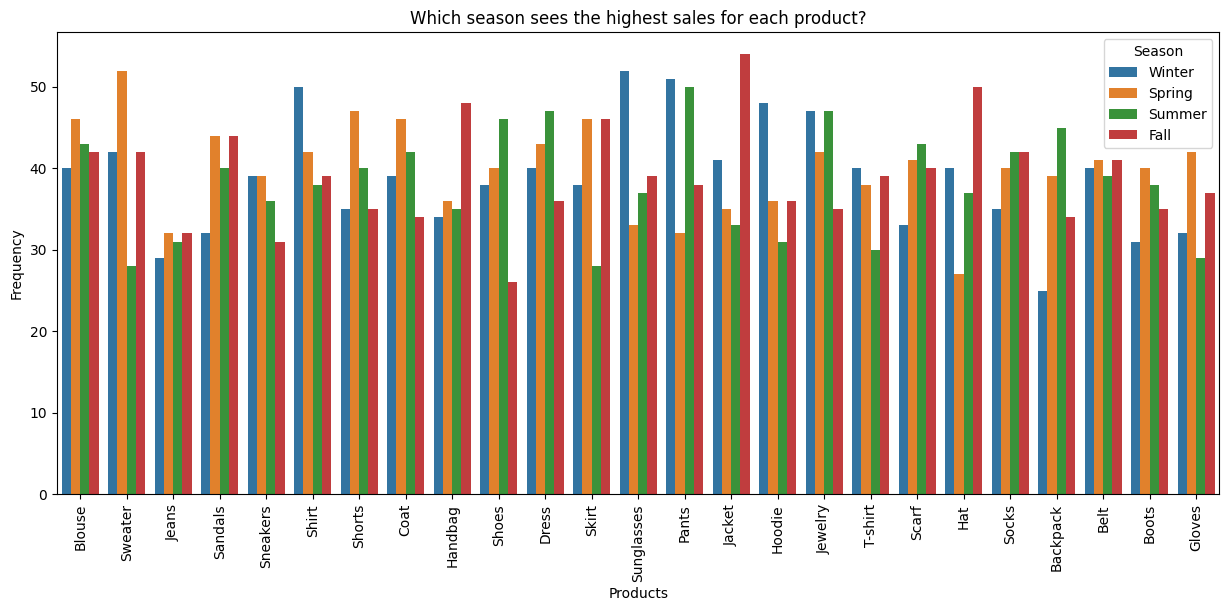

In [154]:
plt.figure(figsize=(15, 6))
sns.countplot(data = dataset, x = "Item Purchased", hue = "Season")
plt.xticks(rotation = 90)
plt.title("Which season sees the highest sales for each product?")
plt.xlabel('Products')
plt.ylabel('Frequency')
plt.show()

# Which season sees the highest sales for each Category?

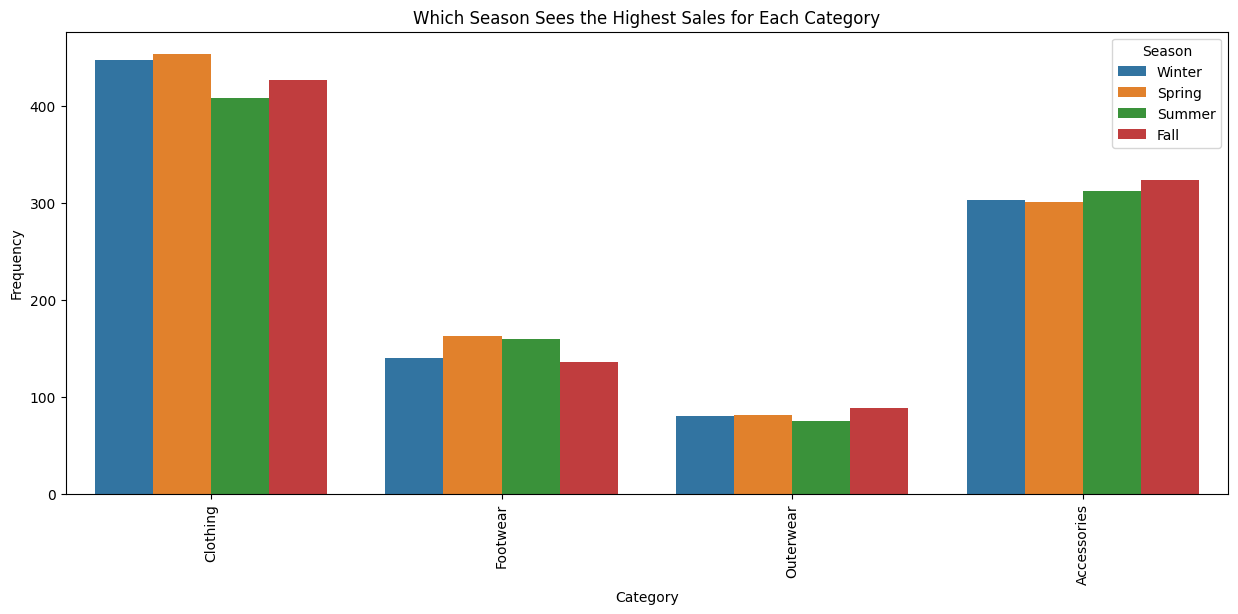

In [162]:
plt.figure(figsize=(15, 6))
ax = sns.countplot(data=dataset, x="Category", hue="Season")
plt.xticks(rotation=90)
plt.title("Which Season Sees the Highest Sales for Each Category")
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

# Which discount has the highest impact on sales?

In [167]:
dataset['Discount Applied'].value_counts()

No     2223
Yes    1677
Name: Discount Applied, dtype: int64

In [165]:
dataset.groupby("Discount Applied")['Purchase Amount (USD)'].sum()

Discount Applied
No     133670
Yes     99411
Name: Purchase Amount (USD), dtype: int64

In [174]:
dataset.groupby(['Season', 'Discount Applied']).size()

Season  Discount Applied
Fall    No                  578
        Yes                 397
Spring  No                  559
        Yes                 440
Summer  No                  532
        Yes                 423
Winter  No                  554
        Yes                 417
dtype: int64

# High-rating products with ratings greater than 4.5

In [199]:
pd.DataFrame(dataset[dataset['Review Rating'] > 4.5]['Item Purchased']).value_counts()

Item Purchased
Sandals           36
Belt              34
Gloves            32
Boots             31
Dress             31
Hoodie            31
Pants             30
Sweater           30
Sunglasses        30
Blouse            29
Jewelry           27
Sneakers          27
Shirt             27
T-shirt           27
Jacket            27
Hat               27
Handbag           27
Scarf             26
Shoes             26
Shorts            26
Skirt             26
Socks             26
Backpack          26
Coat              23
Jeans             18
dtype: int64

# Low-rating products with ratings lessthan than 3.5 

In [206]:
pd.DataFrame(dataset[dataset['Review Rating'] < 3]['Item Purchased']).value_counts()

Item Purchased
Shirt             39
Coat              35
Pants             34
Shorts            33
Scarf             33
Sweater           31
Sandals           31
Jewelry           28
Blouse            28
Socks             28
Handbag           28
Hoodie            28
Jeans             28
Jacket            27
Sunglasses        27
Belt              26
Skirt             26
Gloves            24
Dress             24
Sneakers          23
T-shirt           23
Shoes             22
Boots             22
Backpack          21
Hat               16
dtype: int64